Summary data loaded from exp5_summary.json:
My run values: [0.2453507292118227, 0.3453196159717899, 0.3522631944507454, 0.33548043591147036, 0.4944849690539346, 0.011111111111111112]


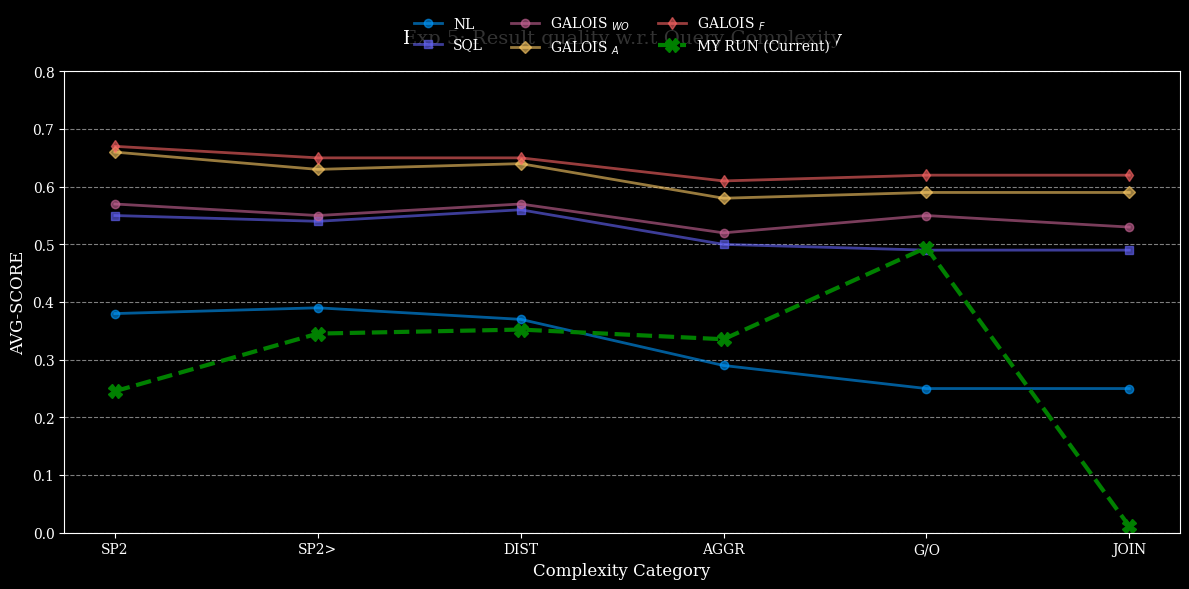

In [2]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

# Questo comando magico fa apparire i grafici direttamente nel notebook
%matplotlib inline

# ==========================================
# 1. DATI (Modifica qui i tuoi numeri!)
# ==========================================

# Categorie di complessità (Asse X)
categories = ['SP2', 'SP2>', 'DIST', 'AGGR', 'G/O', 'JOIN']

# Dati Baseline (Approssimati dal Paper)
data_paper_quality = {
    'NL':        [0.38, 0.39, 0.37, 0.29, 0.25, 0.25],
    'SQL':       [0.55, 0.54, 0.56, 0.50, 0.49, 0.49],
    'GALOIS_WO': [0.57, 0.55, 0.57, 0.52, 0.55, 0.53],
    'GALOIS_A':  [0.66, 0.63, 0.64, 0.58, 0.59, 0.59],
    'GALOIS_F':  [0.67, 0.65, 0.65, 0.61, 0.62, 0.62]
}

# --- I TUOI RISULTATI ATTUALI ---
# Copia qui i valori che leggi dal terminale dopo aver eseguito exp_5_runner.py
# my_run_values = [0.2342, 0.4524, 0.3987, 0.2917, 0.4679, 0.0000]

summary_file = "exp5_summary.json"
if os.path.exists(summary_file):
    with open(summary_file, "r") as f:
        summary_data = json.load(f)
    print(f"Summary data loaded from {summary_file}:")

    my_run_values = [summary_data.get(cat, 0.0) for cat in categories]
    print(f"My run values: {my_run_values}")
else:
    print(f"Summary file {summary_file} not found!")
    my_run_values = [0.0] * len(categories)

# ==========================================
# 2. CONFIGURAZIONE GRAFICA
# ==========================================

# Definizione stili (Colori e Simboli)
styles = {
    'NL':        {'color': '#0099ff', 'marker': 'o', 'linestyle': '-', 'label': 'NL'},
    'SQL':       {'color': '#6666ff', 'marker': 's', 'linestyle': '-', 'label': 'SQL'},
    'GALOIS_WO': {'color': '#cc6699', 'marker': 'o', 'linestyle': '-', 'label': r'GALOIS $_{WO}$'},
    'GALOIS_A':  {'color': '#ffcc66', 'marker': 'D', 'linestyle': '-', 'label': r'GALOIS $_A$'},
    'GALOIS_F':  {'color': '#ff6666', 'marker': 'd', 'linestyle': '-', 'label': r'GALOIS $_F$'},
    'MY RUN':    {'color': 'green',   'marker': 'X', 'linestyle': '--', 'linewidth': 3, 'label': 'MY RUN (Current)'}
}

# Creazione Figura
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'serif'

# ==========================================
# 3. PLOT
# ==========================================

# A. Plotta le Baseline
for name, values in data_paper_quality.items():
    s = styles[name]
    plt.plot(categories, values,
             color=s['color'], marker=s['marker'], linestyle=s['linestyle'],
             label=s['label'], linewidth=2, markersize=6, alpha=0.6)

# B. Plotta la TUA linea (in evidenza)
s_my = styles['MY RUN']
plt.plot(categories, my_run_values,
         color=s_my['color'], marker=s_my['marker'], linestyle=s_my['linestyle'],
         label=s_my['label'], linewidth=3, markersize=10)

# ==========================================
# 4. PERSONALIZZAZIONE FINALE
# ==========================================

plt.title("Exp 5: Result quality w.r.t Query Complexity", fontsize=14, pad=20)
plt.ylabel("AVG-SCORE", fontsize=12)
plt.xlabel("Complexity Category", fontsize=12)
plt.ylim(0, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legenda esterna in alto
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=True, edgecolor='black')

plt.tight_layout()
plt.show()